In [24]:
import geopandas as gpd
import pandas as pd
import numpy as np
# from numpy import infinity
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib .patches import Patch, Rectangle
from shapely.geometry import Point
from shapely.geometry import LineString

commute21 = pd.read_csv(r"../data/sodb_2021_dochadzka_denne_lm_rk.csv", encoding="windows-1250")
commute11 = pd.read_csv(r"../data/dochadzka_zamestnanie_sodb_2011.csv", sep=";")
commute01 = pd.read_csv(r"../data/dochadzka_zamestnanie_sodb_2001.csv", sep=";")

obce = gpd.read_file(r"../data/liptov_obce.csv", encoding = "windows-1250")
map2 = gpd.read_file(r"../data/geo/liptov.shp")
okresy = gpd.read_file(r"../data/geo/liptov_okresy.shp")
lipt_colors = pd.read_csv(r"../data/colors.csv", sep=";")
map2.drop(columns = ["DOW", "FACC", "IDN3", "NM3", "IDN2", "NM2", "NUTS1", "NUTS1_CODE", "NUTS2", "NUTS2_CODE", "NUTS3", "NUTS3_CODE", "LAU1", "LAU1_CODE", "LAU2", "LAU2_CODE", "VYMERA", "Shape_Area", "Shape_Leng"], inplace = True)
commute11 = (commute11).rename(columns = {"obecA": "obecA", "obecB": "obecB", "POCET": "pocet11"})
commute01 = (commute01).rename(columns = {"Obec trvaleho pobytu": "obecA", "Miesto pracoviska (obec)": "obecB", "POCET": "pocet01"})

commute21[["obecA", "obecB"]] = commute21[["obecA", "obecB"]].astype(str)
commute21["pocet"] = commute21["pocet"].astype(int)
commute11[["obecA", "obecB"]] = commute11[["obecA", "obecB"]].astype(str)
commute11["pocet11"] = commute11["pocet11"].astype(int)
commute01[["obecA", "obecB"]] = commute01[["obecA", "obecB"]].astype(str)
commute01["pocet01"] = commute01["pocet01"].astype(int)


lipt_colors["obec_id"] = lipt_colors["obec_id"].astype(str)
map2["IDN4"] = map2["IDN4"].astype(str)
obce["kod"] = obce["kod"].astype(str)

unique_obce = map2["IDN4"].apply(str).tolist()

commute11 = commute11[commute11["Periodicita dochadzky"] == 1]
commute11 = commute11[commute11["obecA"].isin(unique_obce) & commute11["obecB"].isin(unique_obce)]
commute01 = commute01[commute01["Periodicita dochadzky"] == 1]
commute01 = commute01[commute01["obecA"].isin(unique_obce) & commute01["obecB"].isin(unique_obce)]

obce_gdf = gpd.GeoDataFrame(
    obce,
    geometry=[Point(xy) for xy in zip(obce["x"], obce["y"])],
    crs="EPSG:5514"
)
print(obce.columns)

Index(['code', 'nazov', 'kod_obce', 'typ', 'okMesto', 'kMesto', 'IDN3', 'NM3',
       'IDN2', 'NM2', 'NAZOVOBCE', 'KODOBCE', 'nazov_1', 'kod', 'obyv', 'x',
       'y'],
      dtype='object')


In [2]:
all21 = (
    commute21
    .groupby("obecB", group_keys = False)["pocet"]
    .sum()
)
outer21 = (
    commute21[commute21["obecA"] != commute21["obecB"]]
    .groupby("obecB", group_keys=False)["pocet"]
    .sum()
)
inter21 = (
    commute21[commute21["obecA"] == commute21["obecB"]]
    .groupby("obecB", group_keys=False)["pocet"]
    .sum()
)

all21_df = all21.reset_index().rename(columns = {"pocet": "spolu21"})
inter21_df = inter21.reset_index().rename(columns = {"pocet": "v_obci21"})
outer21_df = outer21.reset_index().rename(columns = {"pocet": "mimo_obce21"})

table21 = all21_df.merge(
    inter21_df.merge(
    outer21_df,
    on = "obecB",
    how = "left"
), on = "obecB", how = "left").fillna(0)
table21["mimo_percent21"] = (table21["mimo_obce21"]/table21["spolu21"]*100).round(1)
table21["vnutri_percent21"] = (table21["v_obci21"]/table21["spolu21"]*100).round(1)
print(table21)

     obecB  spolu21  v_obci21  mimo_obce21  mimo_percent21  vnutri_percent21
0   507300       82      18.0         64.0            78.0              22.0
1   507393        3       2.0          1.0            33.3              66.7
2   507407        7       5.0          2.0            28.6              71.4
3   510262     9277    5181.0       4096.0            44.2              55.8
4   510271       11       6.0          5.0            45.5              54.5
..     ...      ...       ...          ...             ...               ...
75  511188        6       2.0          4.0            66.7              33.3
76  511196      483      51.0        432.0            89.4              10.6
77  511200       21      10.0         11.0            52.4              47.6
78  558281      142      26.0        116.0            81.7              18.3
79  580287       23      11.0         12.0            52.2              47.8

[80 rows x 6 columns]


In [3]:
all11 = (
    commute11
    .groupby("obecB", group_keys = False)["pocet11"]
    .sum()
)
outer11 = (
    commute11[commute11["obecA"] != commute11["obecB"]]
    .groupby("obecB", group_keys=False)["pocet11"]
    .sum()
)
inter11 = (
    commute11[commute11["obecA"] == commute11["obecB"]]
    .groupby("obecB", group_keys=False)["pocet11"]
    .sum()
)

all11_df = all11.reset_index().rename(columns = {"pocet11": "spolu11"})
inter11_df = inter11.reset_index().rename(columns = {"pocet11": "v_obci11"})
outer11_df = outer11.reset_index().rename(columns = {"pocet11": "mimo_obce11"})

table11 = all11_df.merge(
    inter11_df.merge(
    outer11_df,
    on = "obecB",
    how = "left"
), on = "obecB", how = "left").fillna(0)
table11["mimo_percent11"] = (table11["mimo_obce11"]/table11["spolu11"]*100).round(1)
table11["vnutri_percent11"] = (table11["v_obci11"]/table11["spolu11"]*100).round(1)
print(table11)

     obecB  spolu11  v_obci11  mimo_obce11  mimo_percent11  vnutri_percent11
0   507300       32      16.0         16.0            50.0              50.0
1   507393       10       8.0          2.0            20.0              80.0
2   507407        7       4.0          3.0            42.9              57.1
3   510262    10740    6513.0       4227.0            39.4              60.6
4   510271       30       8.0         22.0            73.3              26.7
..     ...      ...       ...          ...             ...               ...
76  511196      459      85.0        374.0            81.5              18.5
77  511200       35      17.0         18.0            51.4              48.6
78  556807        4       4.0          0.0             0.0             100.0
79  558281      196      48.0        148.0            75.5              24.5
80  580287       53      41.0         12.0            22.6              77.4

[81 rows x 6 columns]


In [4]:
all01 = (
    commute01
    .groupby("obecB", group_keys = False)["pocet01"]
    .sum()
)
outer01 = (
    commute01[commute01["obecA"] != commute01["obecB"]]
    .groupby("obecB", group_keys=False)["pocet01"]
    .sum()
)
inter01 = (
    commute01[commute01["obecA"] == commute01["obecB"]]
    .groupby("obecB", group_keys=False)["pocet01"]
    .sum()
)

all01_df = all01.reset_index().rename(columns = {"pocet01": "spolu01"})
inter01_df = inter01.reset_index().rename(columns = {"pocet01": "v_obci01"})
outer01_df = outer01.reset_index().rename(columns = {"pocet01": "mimo_obce01"})

table01 = all01_df.merge(
    inter01_df.merge(
    outer01_df,
    on = "obecB",
    how = "left"
), on = "obecB", how = "left").fillna(0)
table01["mimo_percent01"] = (table01["mimo_obce01"]/table01["spolu01"]*100).round(1)
table01["vnutri_percent01"] = (table01["v_obci01"]/table01["spolu01"]*100).round(1)
# print(commute01[commute01["obecB"] == "510840"])
# print(outer01_df[outer01_df["obecB"] == "510840"])
print(table01[table01["obecB"] == "510840"])

     obecB  spolu01  v_obci01  mimo_obce01  mimo_percent01  vnutri_percent01
48  510840       12      12.0          0.0             0.0             100.0


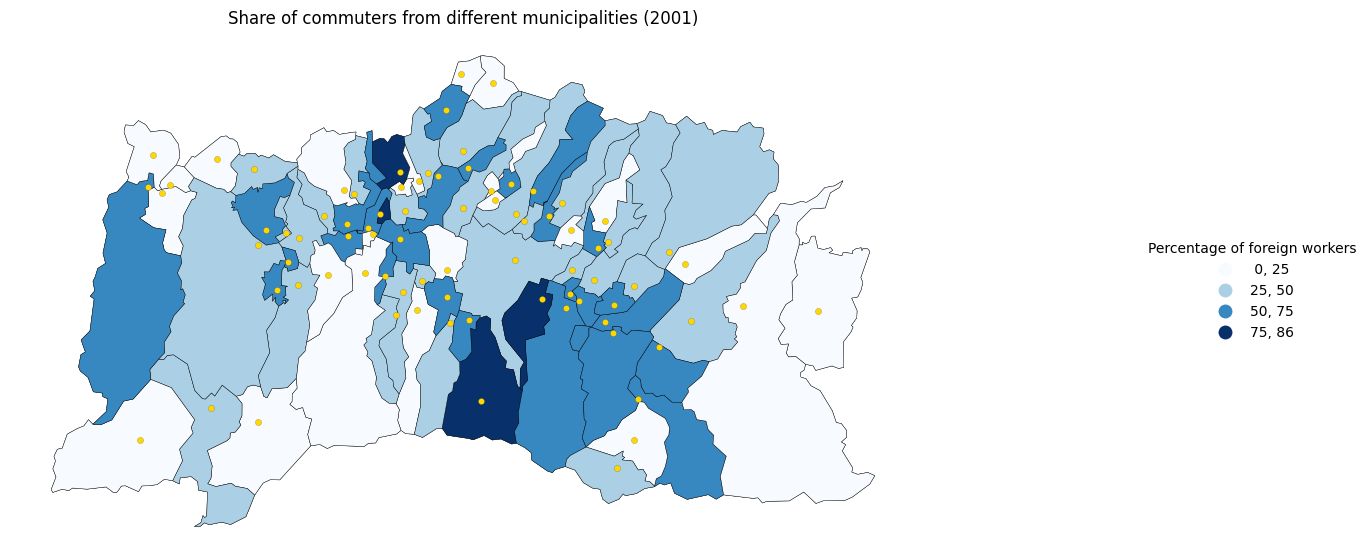

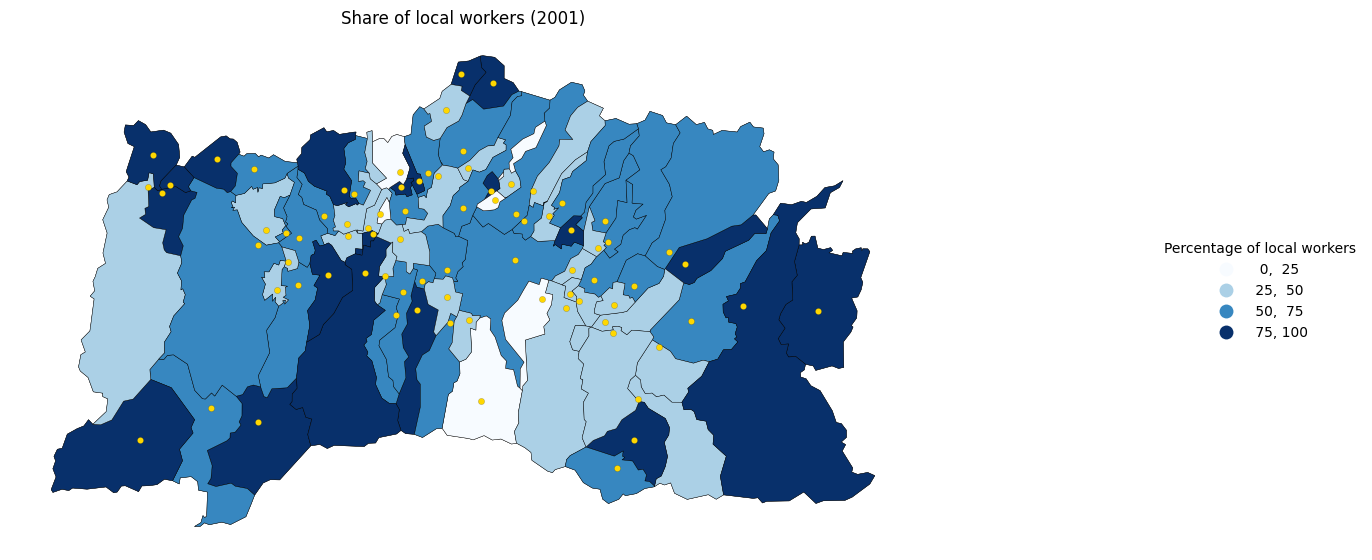

In [5]:
# -------------------------------------------------Share of foreign workers--------------------------------------------------------------

tablemap01 = map2.merge(
    table01,
    left_on = "IDN4",
    right_on = "obecB",
    how = "left"
)

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap01.plot(
    ax = plt.gca(),
    column = "mimo_percent01",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of commuters from different municipalities (2001)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_foreign_workers_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()
# -------------------------------------------------Share of local workers--------------------------------------------------------------

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap01.plot(
    ax = plt.gca(),
    column = "vnutri_percent01",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of local workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of local workers (2001)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_local_workers_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

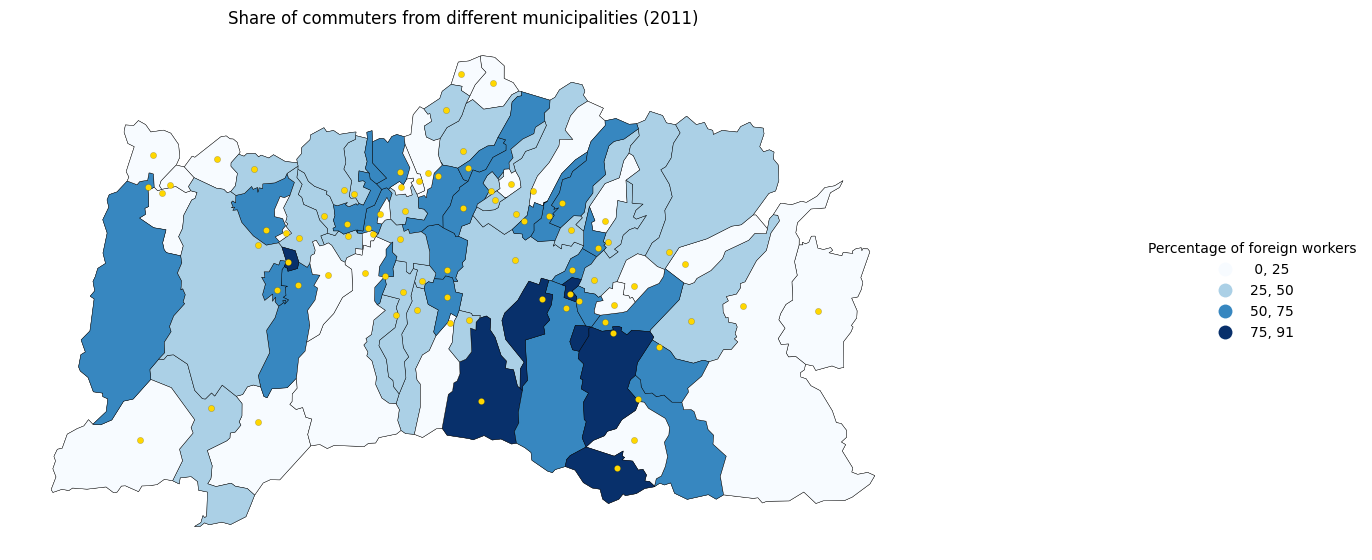

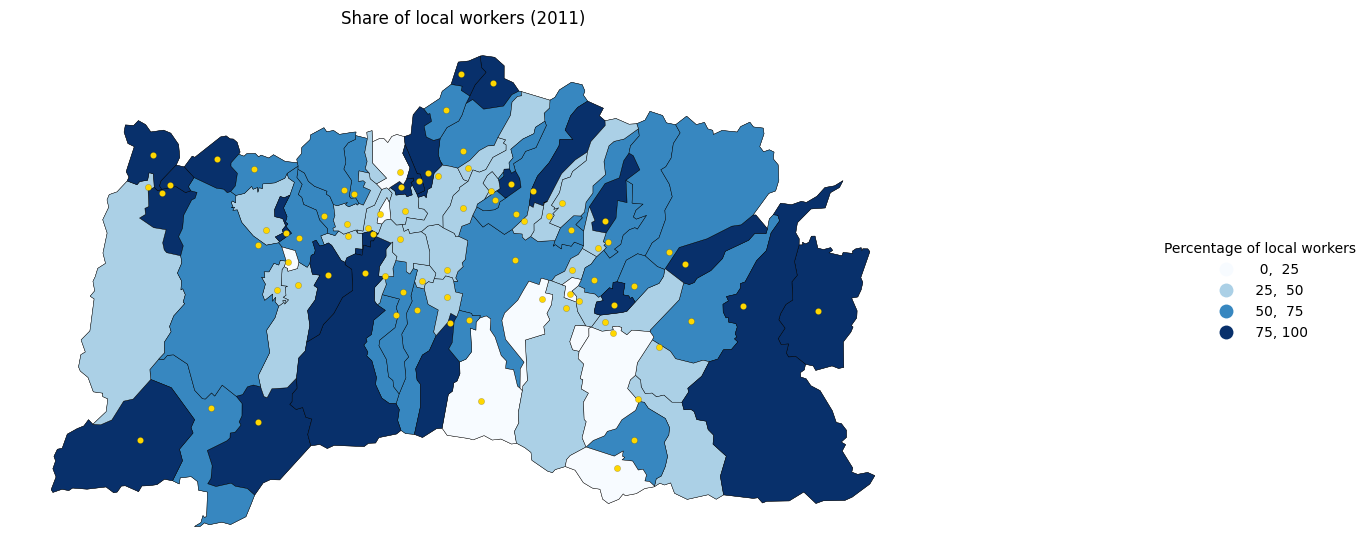

In [6]:
# -------------------------------------------------Share of foreign workers--------------------------------------------------------------

tablemap11 = map2.merge(
    table11,
    left_on = "IDN4",
    right_on = "obecB",
    how = "left"
)

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap11.plot(
    ax = plt.gca(),
    column = "mimo_percent11",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of commuters from different municipalities (2011)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_foreign_workers_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()
# -------------------------------------------------Share of local workers--------------------------------------------------------------

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap11.plot(
    ax = plt.gca(),
    column = "vnutri_percent11",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of local workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of local workers (2011)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_local_workers_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

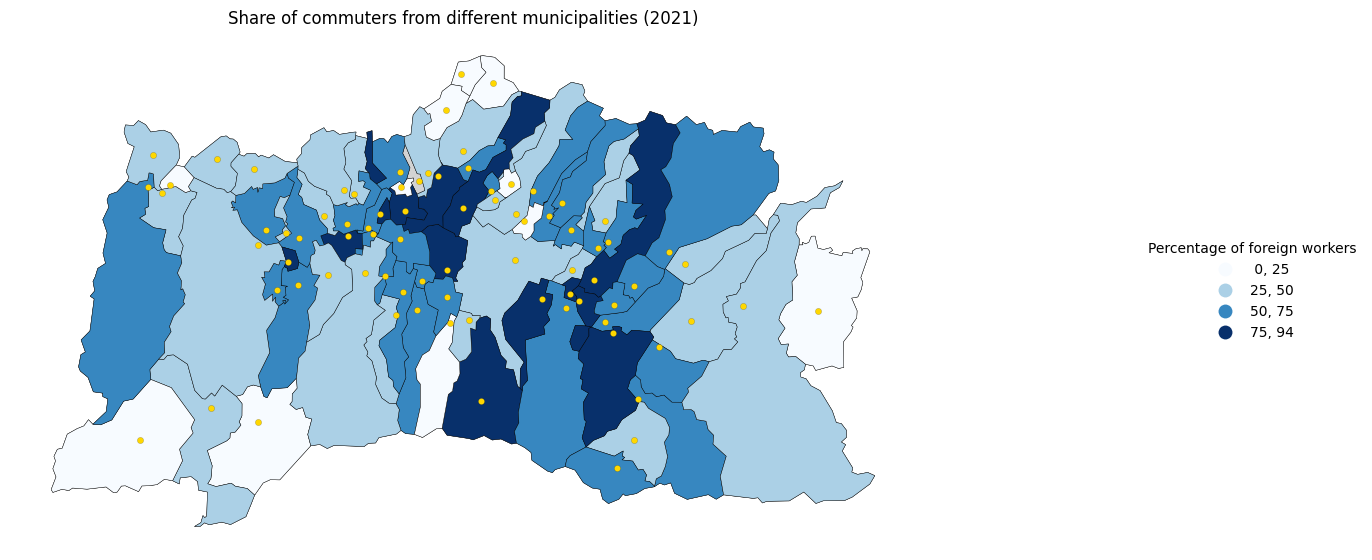

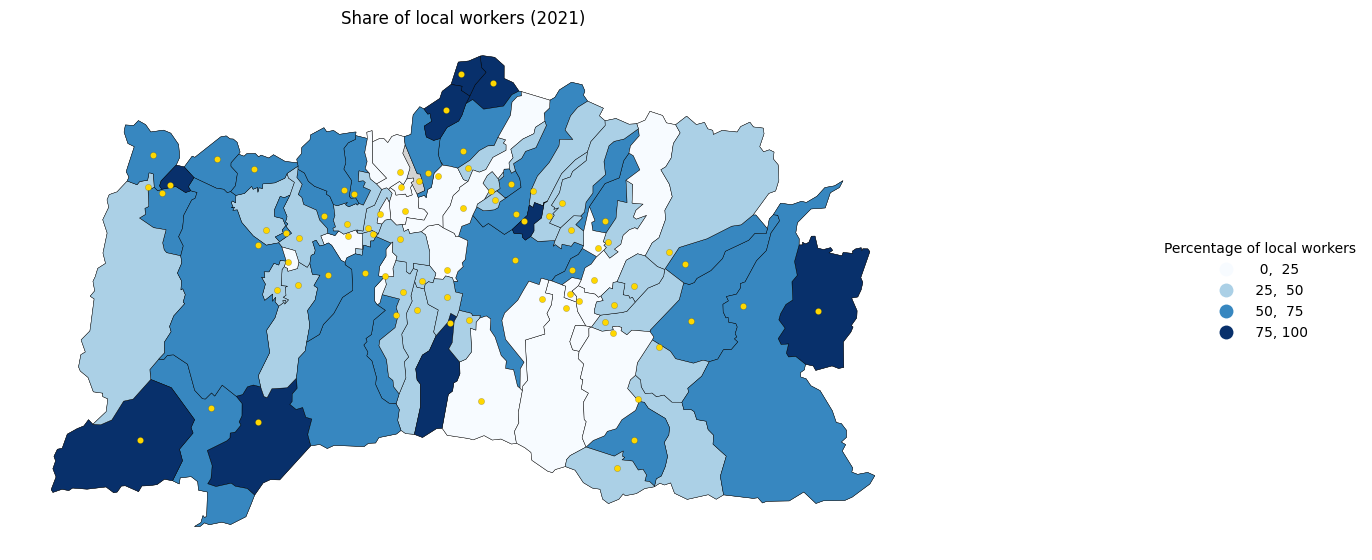

In [7]:
# -------------------------------------------------Share of foreign workers--------------------------------------------------------------

tablemap21 = map2.merge(
    table21,
    left_on = "IDN4",
    right_on = "obecB",
    how = "left"
)

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap21.plot(
    ax = plt.gca(),
    column = "mimo_percent21",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of commuters from different municipalities (2021)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_foreign_workers_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()
# -------------------------------------------------Share of local workers--------------------------------------------------------------

independence_bins = [25, 50, 75]
plt.figure(figsize = (11.69, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
tablemap21.plot(
    ax = plt.gca(),
    column = "vnutri_percent21",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of local workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf.plot(
    ax = plt.gca(),
    color = "gold",
    markersize = 20.0,
    edgecolor = "black",
    linewidth = 0.1
)
plt.title("Share of local workers (2021)")
plt.axis(False)
# plt.savefig("../result_maps/workers/LM_RK_local_workers_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

In [52]:
print((table01["spolu01"].max()/table01["spolu01"].sum())*100, table01["spolu01"].sum())
print(table01.sort_values(by = "spolu01", ascending = False))

38.35382929502009 41065
     obecB  spolu01  v_obci01  mimo_obce01  mimo_percent01  vnutri_percent01
3   510262    15750   10051.0       5699.0            36.2              63.8
59  510998    13332    8545.0       4787.0            35.9              64.1
37  510726     4061    1852.0       2209.0            54.4              45.6
25  510599      447     146.0        301.0            67.3              32.7
32  510670      359      95.0        264.0            73.5              26.5
..     ...      ...       ...          ...             ...               ...
24  510581        5       3.0          2.0            40.0              60.0
54  510921        4       0.0          0.0             0.0               0.0
1   507393        4       3.0          1.0            25.0              75.0
6   510319        3       1.0          2.0            66.7              33.3
33  510688        1       1.0          0.0             0.0             100.0

[81 rows x 6 columns]


In [53]:
print((table11["spolu11"].max()/table11["spolu11"].sum())*100, table11["spolu11"].sum())
print(table11.sort_values(by = "spolu11", ascending = False))

35.49005353248298 30262
     obecB  spolu11  v_obci11  mimo_obce11  mimo_percent11  vnutri_percent11
3   510262    10740    6513.0       4227.0            39.4              60.6
59  510998     9867    5969.0       3898.0            39.5              60.5
37  510726     2971    1153.0       1818.0            61.2              38.8
76  511196      459      85.0        374.0            81.5              18.5
25  510599      369     150.0        219.0            59.3              40.7
..     ...      ...       ...          ...             ...               ...
78  556807        4       4.0          0.0             0.0             100.0
48  510840        3       3.0          0.0             0.0             100.0
9   510351        3       3.0          0.0             0.0             100.0
71  511137        3       2.0          1.0            33.3              66.7
6   510319        1       1.0          0.0             0.0             100.0

[81 rows x 6 columns]


In [54]:
print((table21["spolu21"].max()/table21["spolu21"].sum())*100, table21["spolu21"].sum())
print(table21.sort_values(by = "spolu21", ascending = False))

35.80885474968155 25907
     obecB  spolu21  v_obci21  mimo_obce21  mimo_percent21  vnutri_percent21
3   510262     9277    5181.0       4096.0            44.2              55.8
59  510998     8391    4609.0       3782.0            45.1              54.9
37  510726     2601     902.0       1699.0            65.3              34.7
76  511196      483      51.0        432.0            89.4              10.6
25  510599      356      91.0        265.0            74.4              25.6
..     ...      ...       ...          ...             ...               ...
15  510459        2       2.0          0.0             0.0             100.0
54  510921        2       1.0          1.0            50.0              50.0
66  511072        2       2.0          0.0             0.0             100.0
48  510840        1       1.0          0.0             0.0             100.0
71  511137        1       1.0          0.0             0.0             100.0

[80 rows x 6 columns]


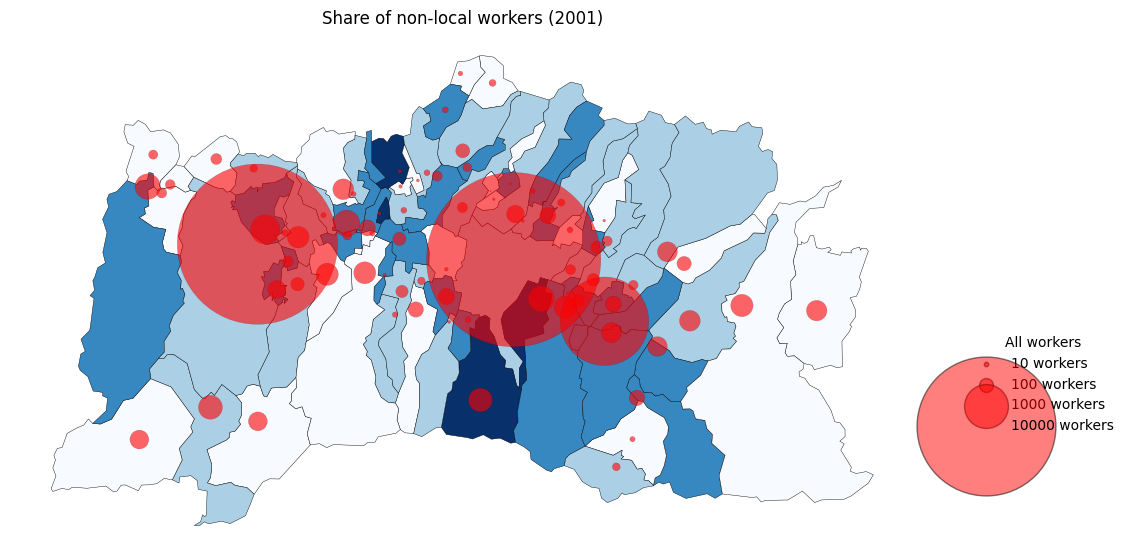

In [33]:
obce_gdf_01 = obce_gdf.merge(
    table01,
    left_on = "kod",
    right_on = "obecB",
    how = "left"
).drop(columns = ["kod_obce", "okMesto", "kMesto", "IDN3", "NM3", "IDN2", "NM2", "NAZOVOBCE", "KODOBCE", "obyv"])
independence_bins = [25, 50, 75]

def scale_size(value, scale = 1):
    return value*scale


# plt.figure(figsize = (11.69, 8.27))
fig, ax = plt.subplots(figsize = (11.67, 8.27))
choropleth = tablemap01.plot(
    ax = ax,
    column = "mimo_percent01",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf_01["markersize01"] = obce_gdf_01["spolu01"].apply(scale_size)
obce_gdf_01.plot(
    ax = ax,
    color = "red",
    markersize = obce_gdf_01["markersize01"],
    alpha = 0.6,
    edgecolor = "black",
    linewidth = 0.1
)
circle_size = [10, 100, 1000, 10000]
legend_circles = [
    plt.scatter([], [], s = scale_size(val), color = "red", alpha = 0.5, edgecolor = "black", label = f"{val} workers")
    for val in circle_size
]

legend1 = ax.legend(
    handles = legend_circles,
    title = "All workers",
    loc = "lower left",
    bbox_to_anchor = (1.05, 0.2),
    frameon = False
)

plt.title("Share of non-local workers (2001)")
plt.axis(False)
plt.savefig("../result_maps/workers/non-local_circles_2001.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

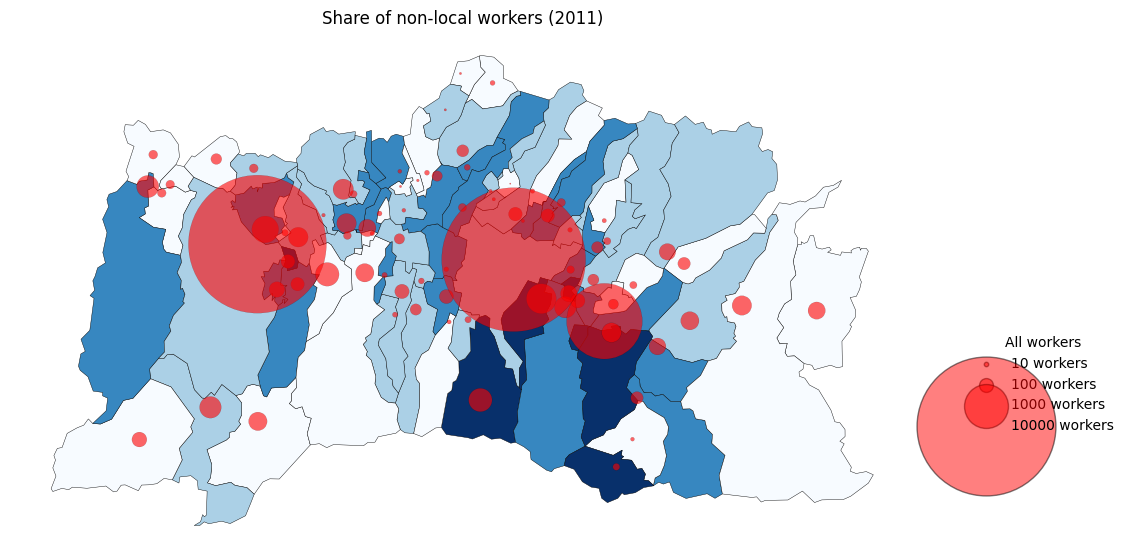

In [34]:
obce_gdf_11 = obce_gdf.merge(
    table11,
    left_on = "kod",
    right_on = "obecB",
    how = "left"
).drop(columns = ["kod_obce", "okMesto", "kMesto", "IDN3", "NM3", "IDN2", "NM2", "NAZOVOBCE", "KODOBCE", "obyv"])
independence_bins = [25, 50, 75]

def scale_size(value, scale = 1):
    return value*scale


# plt.figure(figsize = (11.69, 8.27))
fig, ax = plt.subplots(figsize = (11.67, 8.27))
choropleth = tablemap11.plot(
    ax = ax,
    column = "mimo_percent11",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf_11["markersize11"] = obce_gdf_11["spolu11"].apply(scale_size)
obce_gdf_11.plot(
    ax = ax,
    color = "red",
    markersize = obce_gdf_11["markersize11"],
    alpha = 0.6,
    edgecolor = "black",
    linewidth = 0.1
)
circle_size = [10, 100, 1000, 10000]
legend_circles = [
    plt.scatter([], [], s = scale_size(val), color = "red", alpha = 0.5, edgecolor = "black", label = f"{val} workers")
    for val in circle_size
]

legend1 = ax.legend(
    handles = legend_circles,
    title = "All workers",
    loc = "lower left",
    bbox_to_anchor = (1.05, 0.2),
    frameon = False
)

plt.title("Share of non-local workers (2011)")
plt.axis(False)
plt.savefig("../result_maps/workers/non-local_circles_2011.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()

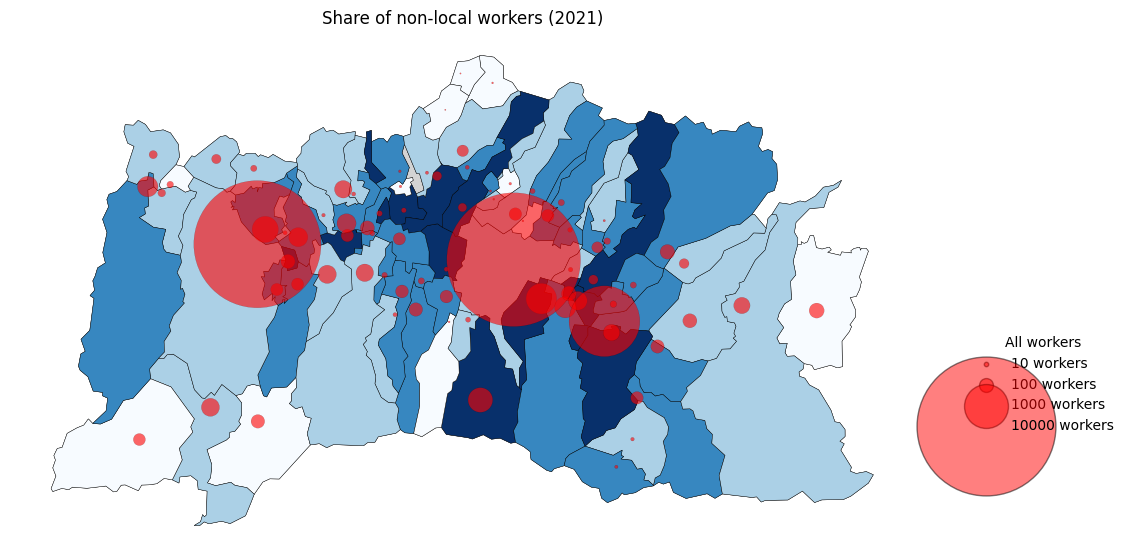

In [35]:
obce_gdf_21 = obce_gdf.merge(
    table21,
    left_on = "kod",
    right_on = "obecB",
    how = "left"
).drop(columns = ["kod_obce", "okMesto", "kMesto", "IDN3", "NM3", "IDN2", "NM2", "NAZOVOBCE", "KODOBCE", "obyv"])
independence_bins = [25, 50, 75]

def scale_size(value, scale = 1):
    return value*scale


# plt.figure(figsize = (11.69, 8.27))
fig, ax = plt.subplots(figsize = (11.67, 8.27))
map2.plot(
    ax = plt.gca(),
    color = "lightgray",
    edgecolor = "black",
    linewidth = 0.3
)
choropleth = tablemap21.plot(
    ax = ax,
    column = "mimo_percent21",
    cmap = "Blues",
    legend = True,
    edgecolor = "black",
    linewidth = 0.3,
    scheme = "user_defined",
    classification_kwds = {"bins": independence_bins},
    legend_kwds = {
        "title": "Percentage of foreign workers",
        "loc": "right",
        "fmt": "{:.0f}",
        "frameon": False,
        "bbox_to_anchor": (1.5, 0.5)
    }
)
obce_gdf_21["markersize21"] = obce_gdf_21["spolu21"].apply(scale_size)
obce_gdf_21.plot(
    ax = ax,
    color = "red",
    markersize = obce_gdf_21["markersize21"],
    alpha = 0.6,
    edgecolor = "black",
    linewidth = 0.1
)
circle_size = [10, 100, 1000, 10000]
legend_circles = [
    plt.scatter([], [], s = scale_size(val), color = "red", alpha = 0.5, edgecolor = "black", label = f"{val} workers")
    for val in circle_size
]

legend1 = ax.legend(
    handles = legend_circles,
    title = "All workers",
    loc = "lower left",
    bbox_to_anchor = (1.05, 0.2),
    frameon = False
)

plt.title("Share of non-local workers (2021)")
plt.axis(False)
plt.savefig("../result_maps/workers/non-local_circles_2021.pdf", format = "pdf", dpi = 300, bbox_inches = "tight")
plt.show()